In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, roc_curve,
    confusion_matrix, roc_auc_score, average_precision_score,
)

FEATURES = [
    'amount_vs_user_avg', 'amount_zscore', 'log_amount',
    'tx_count_1h', 'tx_count_24h', 'amount_sum_24h',
    'is_foreign_country', 'is_high_risk_country',
    'is_high_risk_mcc', 'is_night_tx', 'is_cnp',
]

df = pd.read_csv('../data/transactions_featured.csv', parse_dates=['timestamp'])
X, y = df[FEATURES].fillna(0), df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

with open('../models/xgb_model.pkl', 'rb') as f:
    xgb = pickle.load(f)
with open('../models/threshold.pkl', 'rb') as f:
    threshold = pickle.load(f)

y_proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= threshold).astype(int)
print(f"Using threshold: {threshold:.3f}")

Using threshold: 0.935


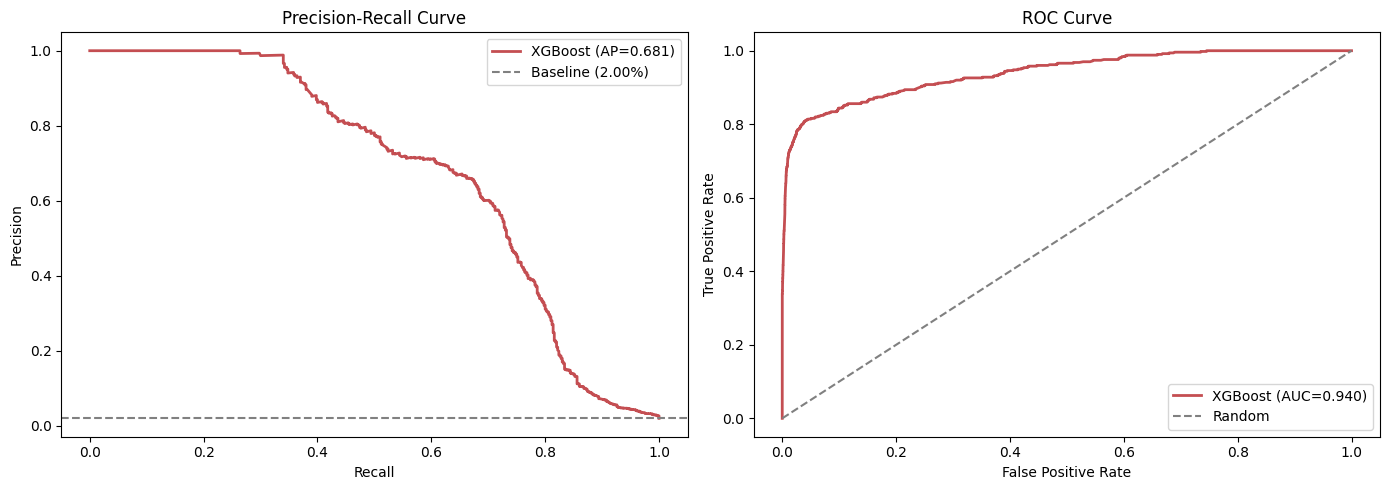

In [2]:
prec, rec, _ = precision_recall_curve(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(rec, prec, color='#C44E52', linewidth=2,
           label=f'XGBoost (AP={average_precision_score(y_test, y_proba):.3f})')
ax[0].axhline(y_test.mean(), color='gray', linestyle='--',
              label=f'Baseline ({y_test.mean():.2%})')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall Curve'); ax[0].legend()

ax[1].plot(fpr, tpr, color='#C44E52', linewidth=2,
           label=f'XGBoost (AUC={roc_auc_score(y_test, y_proba):.3f})')
ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve'); ax[1].legend()
plt.tight_layout(); plt.show()


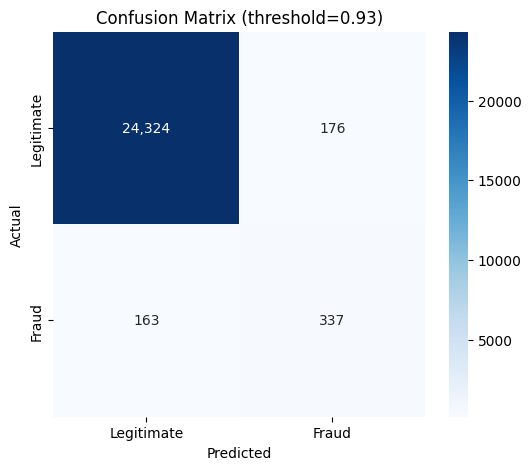

True Positives (caught fraud):   337
False Negatives (missed fraud):  163  ← compliance cost
False Positives (false alarms):  176  ← customer friction
True Negatives (clean traffic):  24,324


In [3]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (threshold={threshold:.2f})')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (caught fraud):   {tp:,}")
print(f"False Negatives (missed fraud):  {fn:,}  ← compliance cost")
print(f"False Positives (false alarms):  {fp:,}  ← customer friction")
print(f"True Negatives (clean traffic):  {tn:,}")

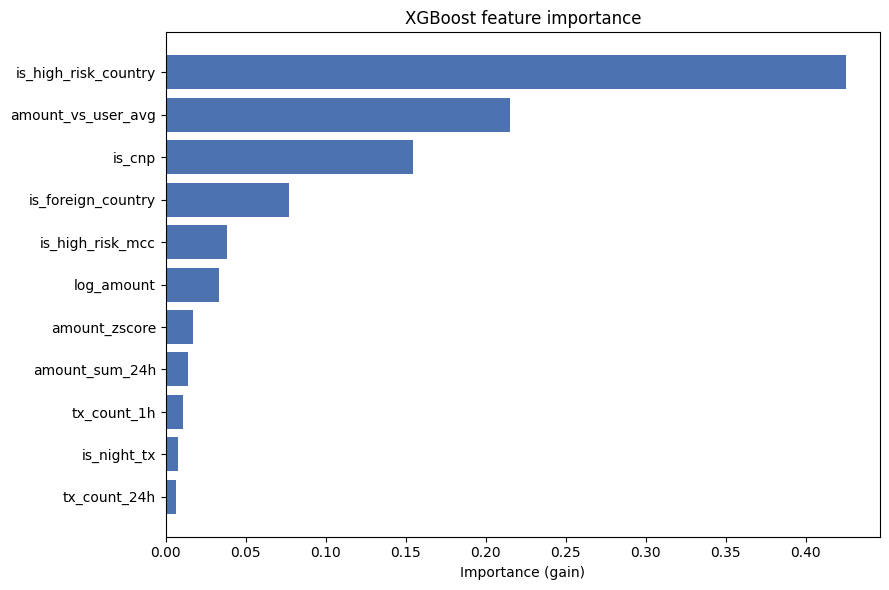

In [4]:
importance = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(importance.index, importance.values, color='#4C72B0')
plt.xlabel('Importance (gain)')
plt.title('XGBoost feature importance')
plt.tight_layout(); plt.show()

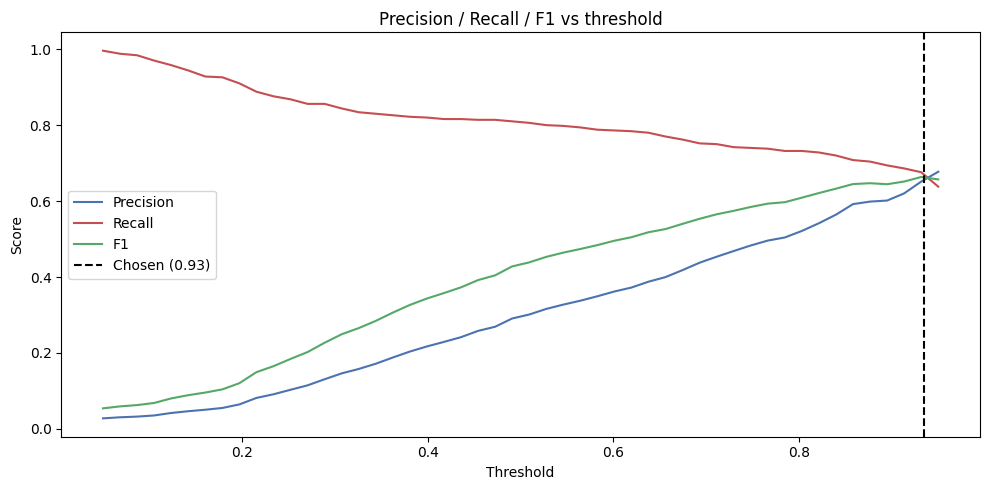

In [5]:
thresholds = np.linspace(0.05, 0.95, 50)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    p = (y_proba >= t).astype(int)
    tp = ((p == 1) & (y_test == 1)).sum()
    fp = ((p == 1) & (y_test == 0)).sum()
    fn = ((p == 0) & (y_test == 1)).sum()
    precisions.append(tp / (tp + fp + 1e-10))
    recalls.append(tp / (tp + fn + 1e-10))
    f1s.append(2 * precisions[-1] * recalls[-1] / (precisions[-1] + recalls[-1] + 1e-10))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='#4C72B0')
plt.plot(thresholds, recalls, label='Recall', color='#C44E52')
plt.plot(thresholds, f1s, label='F1', color='#55A868')
plt.axvline(threshold, color='black', linestyle='--', label=f'Chosen ({threshold:.2f})')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs threshold')
plt.legend(); plt.tight_layout(); plt.show()

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"Threshold: {threshold:.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")

PR-AUC:    0.6812
ROC-AUC:   0.9398
Threshold: 0.9345
Precision: 0.6569
Recall:    0.6740
F1:        0.6654
